# Взаимосвязь переменных

Как мы уже говорили, исследуя изменения случайных величин, мы зачастую обнаруживаем, что между этими изменениями существует взаимосвязь (bivariate relationship, association).

In [394]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Возьмем вот такой простой набор данных.

In [395]:
# создадим искусственный датасет
toy_df = pd.DataFrame({
    'a':[1, 4, 5, 6, 9],
    'b':[2, 3, 5, 6, 8],
    'c':[6, 5, 4, 3, 2],
    'd':[7, 4, 3, 4, 6]
})

toy_df

,a,b,c,d
0,1,2,6,7
1,4,3,5,4
2,5,5,4,3
3,6,6,3,4
4,9,8,2,6


Посмотрим на распределения величин с помощью boxplot.

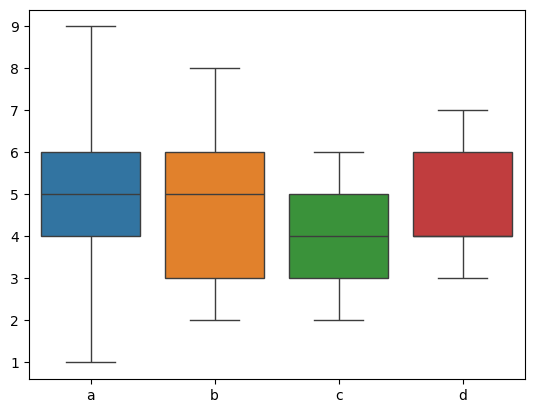

In [396]:
# посмотрим на распределение его переменных
sns.boxplot(data = toy_df);

Очевидно, распределения отличаются друг от друга, однако пока что мы мало можем сказать об этих распределениях или их взаимосвязи.

Начнем с расчета дисперсии.

## Дисперсия
Дисперсия (variance) показывает изменение переменной относительно среднего значения. Приведем формулу для расчета дисперсии генеральной совокупности.
$$ \sigma^2 = \frac{\sum (x_i-\mu)^2}{N} $$
где $\mu$ — среднее генеральной совокупности из $ x_i $ элементов, а $N$ — ее размер. Дисперсию выборки мы рассчитываем немного иначе.
$$ s^2 = \frac{\sum (x_i-\bar{x})^2}{n-1} $$
В данном случае деление на $n-1$, а не на $n$ называется поправкой Бесселя (Bessel’s correction). Зачем нужна такая поправка? Оказывается, можно показать, что сумма квадратов расстояний, то есть числитель формулы, до среднего генсовокупности (population mean) будет всегда больше, чем сумма квадратов расстояний до выборочного среднего (sample mean).

Как следствие, если при расчете выборочной дисперсии делить на $n$, то мы будем постоянно недооценивать дисперсию генсовокупности. Поправка с делением на $ n-1 $ увеличит дисперсию выборки и сделает ее несмещенной оценкой (unbiased estimation) дисперсии генеральной совокупности.

Приведем основные выводы для показателя дисперсии:
* большая дисперсия показывает, что значения далеки от среднего и далеки друг от друга;
* дисперсия не может быть отрицательной;
* нулевая дисперсия означает, что все элементы выборки или генеральной совокупности идентичны.

Замечу, что далее мы в большинстве случаев будем приводить формулы и вычислять именно выборочные показатели.

Найдем дисперсию для переменной a.

In [397]:
# применим формулу дисперсии к первому столбцу
(np.square(toy_df['a'] - toy_df['a'].mean())).sum() / (toy_df.shape[0] - 1)

np.float64(8.5)

Дисперсию для каждой переменной можно измерить с помощью функции np.var() библиотеки Numpy.

In [398]:
# рассчитаем дисперсию по столбцам с делением на n - 1
np.var(toy_df, ddof = 1, axis = 0)

,0
a,8.5
b,5.7
c,2.5
d,2.7


Точно такой же результат можно получить с помощью **метода .var()** библиотеки Pandas.

In [399]:
# ddof = 1 можно не указывать, это параметр по умолчанию
toy_df.var()

,0
a,8.5
b,5.7
c,2.5
d,2.7


Параметр **ddof** означает Delta Degrees of Freedom (дельта степеней свободы) и указывает на размер поправки при расчете дисперсии выборки. Соответственно ddof = 1 как раз использует деление на $n-ddof = n-1$. Как мы видим, дисперсия переменной a существенно больше, чем, например, переменной d.

Показатель дисперсии представляет собой квадрат измеряемых нами величин. Для понимания величины отклонения это не очень удобно. В этом смысле лучше подойдет среднее квадратическое отклонение.

## Среднее квадратическое отклонение

**Среднее квадратическое отклонение** (СКО, standard deviation) как раз вычисляется как корень из дисперсии.
$$ \sigma = \sqrt{\sigma^2} $$
$$ s = \sqrt{s^2} $$
Рассчитаем СКО для первого столбца.

In [400]:
# рассчитаем СКО для первого столбца
np.sqrt((np.square(toy_df['a'] - toy_df['a'].mean())).sum() / (toy_df.shape[0] - 1))

np.float64(2.9154759474226504)

Мы также можем использовать функцию np.std() библиотеки Numpy и метод .std() библиотеки Pandas.

In [401]:
# для расчета СКО будем также делить на n - 1
np.std(toy_df, ddof = 1, axis = 0)

,0
a,2.915476
b,2.387467
c,1.581139
d,1.643168


In [402]:
# опять же, этот параметр установлен по умолчанию, и его можно не указывать
toy_df.std()

,0
a,2.915476
b,2.387467
c,1.581139
d,1.643168


Теперь перейдем к изучению взаимосвязи между переменными. Одним из способов измерения взаимосвязи является ковариация.

## Ковариация
**Ковариация** (covariance) измеряет направление изменения двух переменных. Другими словами она позволяет понять, как изменится одна из двух переменных при изменении второй.
Построим три точечные диаграммы (scatter plots) для переменных a и b, b и c, и c и d соответственно.

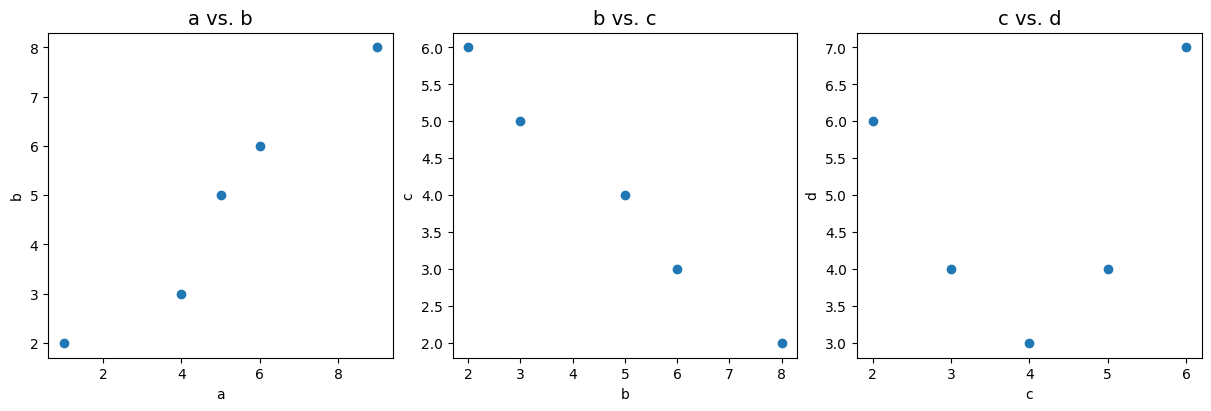

In [403]:
# создадим сетку 1 х 3 с подграфиками для каждой из пар переменных
f, (pair1, pair2, pair3) = plt.subplots(nrows = 1,
                                        ncols = 3,
                                        figsize = (12, 4),
                                        constrained_layout = True)

# в первый подграфик поместим точечную диаграмму переменных a и b
pair1.scatter(toy_df['a'], toy_df['b'])
pair1.set_title('a vs. b', fontsize = 14)
pair1.set(xlabel = 'a')
pair1.set(ylabel = 'b')

# во второй - b и c
pair2.scatter(toy_df['b'], toy_df['c'])
pair2.set_title('b vs. c', fontsize = 14)
pair2.set(xlabel = 'b')
pair2.set(ylabel = 'c')

# в третий - c и d
pair3.scatter(toy_df['c'], toy_df['d'])
pair3.set_title('c vs. d', fontsize = 14)
pair3.set(xlabel = 'c')
pair3.set(ylabel = 'd')

plt.show()

На первом и втором графике мы видим линейную взаимосвязь. Приведем формулу для ее измерения.
$$ Cov_{x, y} = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{n-1} $$
Как вы видите, ковариация представляет собой сумму произведений отклонений переменных от своего среднего значения, усредненную на количество наблюдений ($n-1$).
Рассчитаем ковариацию a и b с помощью Питона.

In [404]:
# рассчитаем ковариацию для переменных a и b
((toy_df['a'] -  toy_df['a'].mean()) * (toy_df['b'] - toy_df['b'].mean())).sum() / (toy_df.shape[0] - 1)

np.float64(6.75)

Если использовать **функцию np.cov()** библиотеки Numpy или метод .cov() библиотеки Pandas, то мы получим так называемую **ковариационную матрицу** (covariance matrix).

In [405]:
# рассчитаем ковариационную матрицу
# для расчета по столбцам нужно использовать параметр rowvar = False
np.cov(toy_df, ddof = 1, rowvar = False)

array([[ 8.5 ,  6.75, -4.5 , -1.  ],
       [ 6.75,  5.7 , -3.75, -0.55],
       [-4.5 , -3.75,  2.5 ,  0.5 ],
       [-1.  , -0.55,  0.5 ,  2.7 ]])

In [406]:
# этот же показатель с помощью библиотеки Pandas
toy_df.cov(ddof = 1)

,a,b,c,d
a,8.50,6.75,-4.50,-1.00
b,6.75,5.70,-3.75,-0.55
c,-4.50,-3.75,2.50,0.50
d,-1.00,-0.55,0.50,2.70


По диагонали указана дисперсия, вне диагонали — ковариация любых двух переменных.

Переменные a и b имеют положительную ковариацию, с увеличением a увеличивается и b. Переменные b и c — отрицательную, переменные c и d демонстрируют нулевую или близкую к нулевой ковариацию.

Интересно, что если переменные независимы (между ними нет взаимосвязи) — ковариация будет равна нулю, при этом обратное не обязательно верно. Если ковариация равна нулю, взаимосвязь может быть, просто она нелинейна (возможно именно такая взаимосвязь существует между c и d).

Недостатком ковариации является то, что она измеряет только направление, но не силу взаимосвязи. Если мы умножим значения обеих переменных, например, на три, то ковариация, исходя из формулы выше, увеличится в девять раз (поскольку как x, так и y каждой пары переменных умножаются на три), при этом очевидно сила взаимосвязи никак не изменится.

In [407]:
# умножим данные на три, рассчитаем ковариацию
# и разделим на ковариационную матрицу исходного датасета,
# чтобы посмотреть масштаб изменения
(toy_df * 3).cov() / toy_df.cov()

,a,b,c,d
a,9.0,9.0,9.0,9.0
b,9.0,9.0,9.0,9.0
c,9.0,9.0,9.0,9.0
d,9.0,9.0,9.0,9.0


Этот недостаток исправляет коэффициент корреляции.

## Корреляция

Корреляция (correlation) между двумя переменными (случайными величинами) измеряет не только направление, но и силу взаимосвязи.
###Параметрические и непараметрические тесты
Прежде чем перейти к различным коэффициентам корреляции, несколько слов про разделение статистических тестов или методов на параметрические и непараметрические.

**Параметрические методы** (parametric methods) основываются на допущении
(assumption) или предпосылке о том, как распределена генеральная совокупность, из которой взята изучаемая выборка. Например, статистический тест может предполагать, что данные имеют нормальное распределение.

**Непараметрические методы** (non-parametric) таких допущений соответственно не предполагают.

На практике это означает, что если допущения параметрического теста не выполняются, его результат нельзя считать достоверным. Для непараметрического теста такое ограничение отсутствует.

### Коэффициент корреляции Пирсона
**Коэффициент корреляции Пирсона** (Pearson correlation coefficient) — это параметрический тест, который строится на основе расчета ковариации двух переменных, разделенного на произведение СКО каждой из них.
$$ r_{pearson} = \frac{Cov_{x, y}}{s_x s_y} $$
Деление на произведение СКО $(s_x s_y)$ выражает любой коэффициент ковариации в единицах этого произведения (нормализует его). Как следствие, мы получаем возможность сравнения коэффициентов корреляции, а значит измерения не только направления, но и силы взаимосвязи.

Коэффициент корреляции всегда находится в диапазоне от $-1$ до $1.$

Значения, приближающиеся к $1,$ указывают на сильную положительную линейную корреляцию. Близкие к $-1,$ на сильную отрицательную линейную корреляцию. Околонулевые значения предполагают отсутствие линейной корреляции.

Посмотрим на график возможных вариантов корреляции данных, приведенный на занятии вводного курса.


![](https://drive.google.com/uc?export=view&id=12G_OtOgb8aM_iPBskBcKVldxrZXbWd74)

Библиотека Numpy предлагает нам **функцию np.corrcoef()** для создания **корреляционной матрицы** (correlation matrix) коэффициента Пирсона.

In [408]:
# построим корреляционную матрицу с помощью Numpy
# для расчета корреляции по столбцам используем параметр rowvar = False
np.corrcoef(toy_df, rowvar = False).round(2)

array([[ 1.  ,  0.97, -0.98, -0.21],
       [ 0.97,  1.  , -0.99, -0.14],
       [-0.98, -0.99,  1.  ,  0.19],
       [-0.21, -0.14,  0.19,  1.  ]])

В Pandas мы можем воспользоваться **методом .corr()**.

In [409]:
# теперь воспользуемся Pandas
toy_df.corr().round(2)

,a,b,c,d
a,1.00,0.97,-0.98,-0.21
b,0.97,1.00,-0.99,-0.14
c,-0.98,-0.99,1.00,0.19
d,-0.21,-0.14,0.19,1.00


In [410]:
# в параметрах мы также можем указать метод расчета корреляции
toy_df.corr(method = 'pearson').round(2)

,a,b,c,d
a,1.00,0.97,-0.98,-0.21
b,0.97,1.00,-0.99,-0.14
c,-0.98,-0.99,1.00,0.19
d,-0.21,-0.14,0.19,1.00


Корреляция переменной с самой собой равна единице, что и отражают значения на главной диагонали матрицы. Кроме того, очевидно, что величина X также коррелирует с Y, как Y c X.

Продемонстрируем также, что изменение масштаба данных не отразится на коэффициенте корреляции.

In [411]:
# умножим значения датасета на два и снова рассчитаем коэффициент Пирсона
(toy_df * 2).corr().round(2)

,a,b,c,d
a,1.00,0.97,-0.98,-0.21
b,0.97,1.00,-0.99,-0.14
c,-0.98,-0.99,1.00,0.19
d,-0.21,-0.14,0.19,1.00


###Особенности коэффициента Пирсона
Несколько важных замечаний.

**Замечание 1**. Ни ковариация, ни корреляция **не устанавливают причинно-следственной связи** (correlation does not imply causation).

Например, мы можем наблюдать существенную корреляцию между потреблением мороженого и продажами кондиционеров, при этом изменения в обеих переменных могут быть вызваны третьей, на рассматриваемой нами переменной, в частности, температурой воздуха.

![](https://drive.google.com/uc?export=view&id=1trRK4Blarr4bD0wc7qJOzuMRrSIQC3Jf)

Кроме того, в некоторых случаях корреляция может быть чистой случайностью.

**Замечание 2**. Коэффициент корреляции Пирсона измеряет взаимосвязь (1) количественных переменных и (2) предполагает, что обе переменные имеют нормальное распределение (это и есть упомянутое выше допущение (assumption) параметрического теста).

**Замечание 3**. Как и в случае с ковариацией, отсутствие линейной корреляции не означает отсутствие взаимосвязи. Возможно взаимосвязь есть, но она **нелинейна**.

**Замечание 4**. Более того, на коэффициент корреляции существенное влияние оказывают выбросы (outliers).

Последние два замечения хорошо иллюстрируются **квартетом Энскомба**
(Anscombe’s quartet), набором небольших датасетов (кстати, встроенных в сессионное хранилище Google Colab) с совершенно разными распределениями x и y, но одинаковым средним арифметическим и СКО переменной y, а также одинаковым коэффициентом корреляции Пирсона.
Вначале получим необходимые данные.


In [412]:
# загрузим данные в формате json из сессионного хранилища,
# преобразуем в датафрейм и посмотрим на первые три строки
anscombe = pd.read_json('/content/sample_data/anscombe.json')
anscombe.head(3)

,Series,X,Y
0,I,10,8.04
1,I,8,6.95
2,I,13,7.58


In [413]:
# разобьем данные на четыре части по столбцу Series
series_by_group = [x for _, x in anscombe.groupby('Series')]

# отдельно получим названия каждой из четырех частей
labels = anscombe.Series.unique()
labels

array(['I', 'II', 'III', 'IV'], dtype=object)

In [414]:
# создадим пустой словарь
datasets = {}

# в цикле пройдемся по названиям и значениям переменных x и y каждой из частей
for label, series in zip(labels, series_by_group):
  # каждое название части станет ключом словаря, а переменные x и y - значениями
  datasets[label] = (list(series.X.round(2)), list(series.Y.round(2)))

# выведем содержимое словаря с помощью функции pprint()
from pprint import pprint
pprint(datasets)

{'I': ([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
       [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.81, 5.68]),
 'II': ([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
        [9.14, 8.14, 8.74, 8.77, 9.26, 8.1, 6.13, 3.1, 9.13, 7.26, 4.74]),
 'III': ([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
         [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]),
 'IV': ([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
        [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.5, 5.56, 7.91, 6.89])}


Теперь выведем каждый из четырех датасетов на графиках.

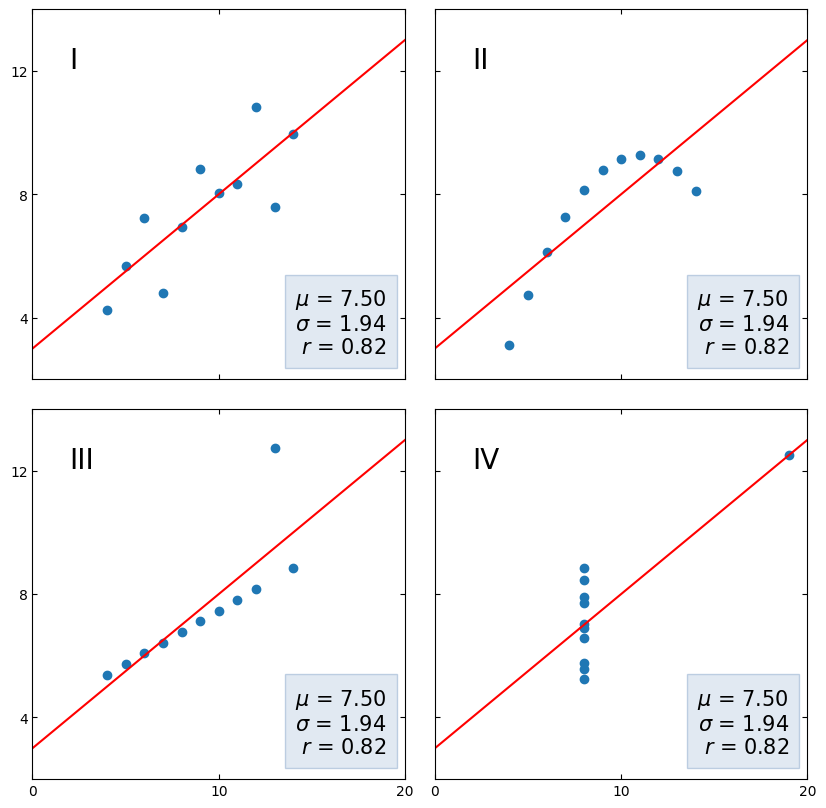

In [415]:
# создадим сетку подграфиков 2 х 2
fig, axs = plt.subplots(2, 2,
                        sharex = True,
                        sharey = True,
                        figsize = (10, 10),
                        gridspec_kw = {'wspace': 0.08, 'hspace': 0.08})

# определим границы осей и отметки на осях x и y
axs[0, 0].set(xlim = (0, 20), ylim = (2, 14))
axs[0, 0].set(xticks = (0, 10, 20), yticks = (4, 8, 12))

# пройдемся по подграфикам, а также ключам и значениям словаря datasets
for ax, (label, (x, y)) in zip(axs.flat, datasets.items()):

    # выведем название (номер) группы
    ax.text(0.1, 0.9, label, fontsize = 20, transform = ax.transAxes, va = 'top')
    ax.tick_params(direction = 'in', top = True, right = True)

    # построим точечные диаграммы
    ax.scatter(x, y)

    # обучим модель линейной регрессии
    slope, intercept = np.polyfit(x, y, deg = 1)

    # выведем график линейной регрессии
    x_vals = np.linspace(0, 20, num = 1000)
    y_vals = intercept + slope * x_vals
    ax.plot(x_vals, y_vals, 'r')

    # рассчитаем среднее арифметическое, СКО и корреляцию Пирсона
    stats = (f'$\\mu$ = {np.mean(y):.2f}\n'
             f'$\\sigma$ = {np.std(y):.2f}\n'
             f'$r$ = {np.corrcoef(x, y)[0][1]:.2f}')

    # создадим отформатированное пространство на графике
    bbox = dict(boxstyle = 'square', pad = 0.5,
                fc = '#c5d4e6',
                ec = '#89a8cc',
                alpha = 0.5)

    # и выведем в нем рассчитанные выше статистические показатели
    ax.text(0.95, 0.07, stats, fontsize = 15,
            bbox = bbox, transform = ax.transAxes,
            horizontalalignment = 'right')

plt.show()

Как мы видим,
* на первом графике прослеживается линейная корреляция без каких-либо сюрпризов;
* во втором наборе данных у нас нелинейная зависимость, силу которой мы не смогли отразить с помощью коэффициента Пирсона;
*8 в третьем наборе коэффициент корреляции находится под сильным влиянием выброса;
* в четвертом, взаимосвязь по сути отсутствует, и тем не менее одного наблюдения оказывается достаточно для появления достаточно сильной корреляции.


#### Коэффициент Пирсона как скалярное произведение векторов
Распишем формулу корреляции более подробно (см. формулы ковариации, дисперсии и СКО).
$$ r_{pearson} = \frac{ \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{n-1} }{ \sqrt {\frac{\sum (x_i-\bar{x})^2}{n-1} \frac{\sum (y_i-\bar{y})^2}{n-1} } } $$
Упростим выражение.
$$ r_{pearson} = \frac{ \sum (x_i-\bar{x})(y_i-\bar{y}) } { \sqrt {\sum (x_i-\bar{x})^2}\sqrt{ \sum (y_i-\bar{y})^2 } } $$
Теперь давайте представим случайные величины X и Y в форме векторов
$$ \textbf{x} = \left[ x_1, x_2, x_3,…, x_n \right] $$
$$ \textbf{y} = \left[ y_1, y_2, y_3,…, y_n \right] $$
со средними значениями $ \bar{x} $ и $ \bar{y} $. Затем определим новые векторы $\textbf{x}^c $ и $ \textbf{y}^c $, в которых из значений $x_i$ и $y_i$ вычтем соответствующие средние значения.
$$ \textbf{x}^c = [x_1-\bar{x}, x_2-\bar{x}, x_3-\bar{x},…, x_n-\bar{x}] $$$$ \textbf{y}^c = [y_1-\bar{x}, y_2-\bar{x}, y_3-\bar{y},…, y_n-\bar{y}] $$
Обратим внимание, что (1) числитель в формуле коэффициента корреляции представляет собой покомпонентное умножение векторов с последующим сложением произведений (то есть скалярное произведение).
Знаменатель (2) же представляет собой покомпонентное умножение и сложение произведений векторов самих на себя. Корень из скалярного произведения вектора на самого себя есть длина этого вектора. Приведем пример для вектора $ \textbf{x}$
$$ \sqrt { \textbf{x}^2 } = \sqrt { \textbf{x} \cdot \textbf{x} } = || \textbf{x} || $$
Исходя из этих двух соображений, перепишем формулу расчета коэффициента Пирсона.
$$ r_{pearson} = \frac { \textbf{x}^c \cdot \textbf{y}^c }{|| \textbf{x}^c || \cdot ||
\textbf{y}^c || } $$
Это формула косинусного сходства двух векторов. Другими словами, коэффициент корреляции равен косинусу угла между двумя векторами данных. Рассчитаем корреляцию через косинусное сходство с помощью Питона.

In [416]:
# возьмем данные первой группы квартета Энскомба
x = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5])
y = np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.81, 5.68])

# вычтем из каждого значения x и y соответствующее среднее арифметическое
xc = x - np.mean(x)
yc = y - np.mean(y)

# используем формулу косинусного сходства и округлим результат
np.round(np.dot(xc, yc)/(np.linalg.norm(xc) * np.linalg.norm(yc)), 2)

np.float64(0.82)

Как уже было сказано, у коэффициента Пирсона есть ряд ограничений, в частности, он выявляет только линейную взаимосвязь количественных переменных. В этой связи рассмотрим коэффициент Спирмена.

### Коэффициент ранговой корреляции Спирмена
Коэффициент ранговой корреляции Спирмена (Spearman’s Rank Correlation Coefficient) хорошо измеряет постоянно возрастающую или постоянно убывающую (монотонную) зависимость двух переменных, а также подходит для работы с категориальными порядковыми данными.

Это непараметрический тест, который не предполагает каких-либо допущений о распределении генеральной совокупности.

####Монотонная зависимость
Напомню, что функция или зависимость называется монотонной (monotonic), если на заданном интервале ее производная (градиент) не меняет знака (то есть всегда имеет неотрицательное или неположительное значение). Приведем пример.

![](https://drive.google.com/uc?export=view&id=10QmVv5fMroFChC_X8NOdGd0GjuOn-wqJ)

Рассмотрим взаимосвязь площади (area) и цены (price) квартиры.


In [417]:
# поместим данные площади и цены квартиры в датафрейм
flats = pd.DataFrame({
    'area'   :[78, 90, 74, 69, 63, 57, 72, 67, 83],
    'price'   :[9.1, 9.0, 8.9, 8.2, 6.0, 5.8, 8.7, 7.5, 9.2]
})

flats

,area,price
0,78,9.1
1,90,9.0
2,74,8.9
3,69,8.2
4,63,6.0
5,57,5.8
6,72,8.7
7,67,7.5
8,83,9.2


Выведем эти данные с помощью точечной диаграммы (scatter plot).

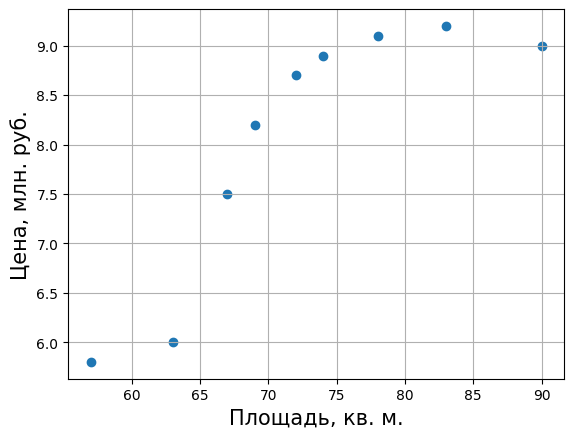

In [418]:
# выведем данные на графике
plt.scatter(flats.area, flats.price)
plt.xlabel('Площадь, кв. м.', fontsize = 15)
plt.ylabel('Цена, млн. руб.', fontsize = 15)
plt.grid()
plt.show()

Рассчитаем коэффициент корреляции Пирсона.

In [419]:
# рассчитаем коэффициент корреляции Пирсона
# выведем одно из значений корреляционной матрицы с помощью .iloc[0, 1] и округлим результат
flats.corr(method = 'pearson').iloc[0, 1].round(2)

np.float64(0.86)

Достаточно высокий уровень корреляции. При этом, как мы видим, зависимость нелинейна и возможно коэффициент Пирсона не до конца уловил силу взаимосвязи. Как нам преодолеть ограничение линейности?

Обратите внимание, прежде чем построить график, Питон упорядочил значения площади (ось x). Другими словами, присвоил им ранг (порядковый номер) от первого до, в данном примере, девятого. В каком случае значения цены (ось y) будут также возрастать? Только в случае, если их ранги мало отличаются от рангов значений площади квартиры.

Коэффициент корреляции Спирмена как раз считает степень отличия рангов двух переменных.

Приведем формулу.
$$ r_{spearman} = \frac{6 \sum d_i^2 }{n(n^{2}-1)} $$
Вычислим коэффициент Спирмена с помощью Питона. Вначале присвоим каждому значению в обоих столбцах ранг (порядковый номер), предварительно упорядочив значения по убыванию.

In [420]:
# присвоим ранг значениям в каждом из столбцов
# для этого используем метод .rank() с параметром ascending = False
flats['area_rank'] = flats.area.rank(ascending = False)
flats['price_rank'] = flats.price.rank(ascending = False)
flats

,area,price,area_rank,price_rank
0,78,9.1,3.0,2.0
1,90,9.0,1.0,3.0
2,74,8.9,4.0,4.0
3,69,8.2,6.0,6.0
4,63,6.0,8.0,8.0
5,57,5.8,9.0,9.0
6,72,8.7,5.0,5.0
7,67,7.5,7.0,7.0
8,83,9.2,2.0,1.0


Таким образом площади дома в 90 квадратных метров и цене в 9,2 миллона рублей будет присвоен ранг 1. Теперь мы можем вычислить разницу рангов для каждого из наблюдений и возвести ее в квадрат.

In [421]:
# вычтем из рангов площади ранги цены
flats['diff'] = flats['area_rank'] - flats['price_rank']
# возведем разницу в квадрат
flats['diff_sq'] = np.square(flats['diff'])
flats

,area,price,area_rank,price_rank,diff,diff_sq
0,78,9.1,3.0,2.0,1.0,1.0
1,90,9.0,1.0,3.0,-2.0,4.0
2,74,8.9,4.0,4.0,0.0,0.0
3,69,8.2,6.0,6.0,0.0,0.0
4,63,6.0,8.0,8.0,0.0,0.0
5,57,5.8,9.0,9.0,0.0,0.0
6,72,8.7,5.0,5.0,0.0,0.0
7,67,7.5,7.0,7.0,0.0,0.0
8,83,9.2,2.0,1.0,1.0,1.0


Выполним оставшиеся вычисления в соответствии с приведенной выше формулой.

In [422]:
# поместим количество наблюдений в переменную n
n = flats.shape[0]

# применим формулу для расчета коэффициента Спирмена
1 - ((6 * flats['diff_sq'].sum()) / (n * (n**2 - 1)))

np.float64(0.95)

Рассчитаем корреляцию Спирмена с помощью метода .corr() библиотеки Pandas с параметром method = ‘spearman’ .

In [423]:
# применим метод .corr() с параметром method = 'spearman'
flats[['area', 'price']].corr(method = 'spearman').iloc[0, 1].round(2)

np.float64(0.95)

Как мы видим, этот коэффициент гораздо лучше уловил монотонную нелинейную зависимость двух переменных.

Также замечу, что коэффициент корреляции Спирмена менее чувствителен к выбросам, находящимся на «краях» обеих выборок, потому что опять же учитывает не само значение, а присвоенный ему ранг.

#### Категориальные порядковые данные

Как уже было сказано, помимо количественных значений коэффициент Спирмена способен измерить направление и силу взаимосвязи категориальных порядковых значений (categorical ordinal data).

Это могут быть оценки уровня удовлетворености клиента (очень понравилось, понравилось, не понравилось), размеры, выраженные категорией $(S, M, L, \ldots)$ и так далее.

В качестве примера рассмотрим оценку собственного самочувствия по шкале от 1 до 10, которую пациенты поставили себе до и после нового метода лечения.

In [424]:
# создадим датафрейм с данными о самочувствии
treatment = pd.DataFrame(
    [
        [3, 2],
        [4, 3],
        [2, 1],
        [1, 5],
        [6, 7],
        [7, 6],
        [5, 4]
    ],
    columns = ['Before', 'After'])

treatment

,Before,After
0,3,2
1,4,3
2,2,1
3,1,5
4,6,7
5,7,6
6,5,4


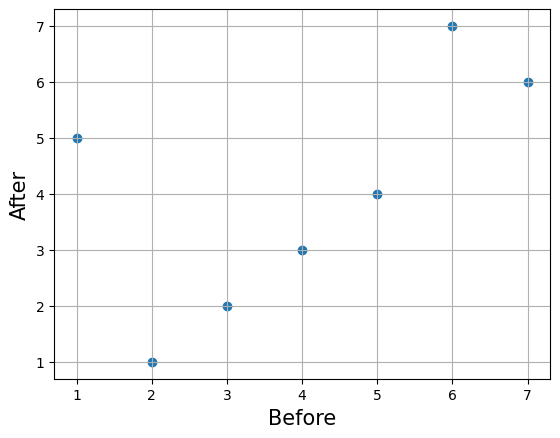

In [425]:
# выведем данные на графике
plt.scatter(treatment.Before, treatment.After)
plt.xlabel('Before', fontsize = 15)
plt.ylabel('After', fontsize = 15)
plt.grid()
plt.show()

По всей видимости корреляция должна быть меньше, чем в предыдущем примере. Приступим к измерениям. Сделать это на самом деле очень просто, потому что порядковые значения уже сами по себе представляют собой ранги. Остается только найти квадрат их разности и применить формулу коэффициента корреляции.

In [426]:
# найдем квадрат разницы рангов
treatment['diff'] = treatment['Before'] - treatment['After']
treatment['diff_sq'] = np.square(treatment['diff'])
treatment

,Before,After,diff,diff_sq
0,3,2,1,1
1,4,3,1,1
2,2,1,1,1
3,1,5,-4,16
4,6,7,-1,1
5,7,6,1,1
6,5,4,1,1


In [427]:
# применим формулу коэффициента корреляции Спирмена
n = treatment.shape[0]
round(1 - ((6 * treatment['diff_sq'].sum()) / (n * (n**2 - 1))), 2)

np.float64(0.61)

Остается сравнить с методом **.corr()** библиотеки Pandas.

In [428]:
# применим метод .corr() библиотеки Pandas
treatment[['Before', 'After']].corr(method = 'spearman').iloc[0, 1].round(2)

np.float64(0.61)

Обратите внимание, ни в количественных данных, ни в порядковых у нас не было повторяющихся или совпадающих наблюдений. В случае **совпадающих наблюдений** (tied ranks), то есть когда значения x или y повторяются, расчет коэффициента корреляции Спирмена также возможен, но немного усложняется.

### Коэффициент ранговой корреляции Кендалла
**Коэффициент ранговой корреляции Кендалла** (еще говорят тау Кендалла или тау-коэффициент, Kendall’s $\tau$ rank correlation coefficient), как и метод Спирмена, может применяться для измерения силы взаимосвязи количественных и порядковых категориальных переменных и подходит для анализа нелинейных зависимостей. Это также непараметрический тест.

Смысл и методику расчета коэффициента Кендалла легко понять на примере. Вновь возьмем данные о самочувствии до и после лечения.

In [429]:
# вновь возьмем данные о самочувствии до и после лечения
# вернем датафрейм к исходному виду
treatment = treatment[['Before', 'After']]
treatment

,Before,After
0,3,2
1,4,3
2,2,1
3,1,5
4,6,7
5,7,6
6,5,4


Теперь рассмотрим две пары наблюдений, например, под индексом 0 и 1.

In [430]:
treatment.head(2)

,Before,After
0,3,2
1,4,3


Мы видим, что в столбце Before значения наблюдения 0 меньше, чем значение наблюдения 1 (потому что 3 < 4). То же самое можно наблюдать в столбце After (2 < 3). Такая пара наблюдений называется конкордантной (concordant). Конкордантной будет и пара наблюдений, где оба значения в первом наблюдении больше обоих значений во втором. К ним относятся, например, пары 1 и 2 (где 4 > 2, а 3 > 1).

In [431]:
treatment.loc[1:2,:]

,Before,After
1,4,3
2,2,1


Если же описанные выше условия не выполняются, то такая пара наблюдений
будет называться **дискордантной** (discordant). К таким наблюдениям относятся,
например, наблюдения 4 и 5 (6 > 7, но 7 < 6).

In [432]:
treatment.loc[4:5,:]

,Before,After
4,6,7
5,7,6


Отнесем каждую из пар нашего датасета к одному из этих классов.

In [433]:
# C - конкордантная пара, D - дискордантная

# 0
# 1 C
# 2 C  C
# 3 D  D  D
# 4 C  C  C  C
# 5 C  C  C  C  D
# 6 C  C  C  D  C  C
#   0  1  2  3  4  5  6

Получилось 16 конкордантных (C) и 5 дискордантных (D) пар. Их общее
количество очевидно равно 21. Это значение удобно посчитать по формуле
сочетаний.
$$ C(n, r) = \frac{n!}{(n-r)! r!} \rightarrow C(7, 2) = \frac{7!}{(7-2)! 2!} = 21 $$
где $n$ — количество наблюдений, а $r$ равно двум, потому что мы ищем
сочетания пар элементов. Можно воспользоваться и упрощенной формулой.
$$ C(r) = \frac{(n \cdot (n-1))}{2} \rightarrow C(7) = \frac{7 \cdot (7-1)}{2} = 21 $$

In [434]:
# найдем количество парных сочетаний
n = 7
pairs = (7 * (7 - 1)) // 2
pairs

21

Так вот, коэффициент корреляции Кендалла показывает соотношение
конкордантных и дискордантных пар по следующей формуле.
$$ \tau = \frac{\text{concordant pairs}-\text{discordant pairs}}{\text{total pairs}}$$
Применим ее к нашему датасету.

In [435]:
# найдем коэффициент корреляции Кендалла
concordant = 16
discordant = pairs - concordant

np.round((concordant - discordant) / pairs, 2)

np.float64(0.52)

Точно такого же результата можно добиться с помощью метода **.corr()** библиотеки
Pandas.

In [436]:
# воспользуемся методом .corr() библиотеки Pandas
treatment.corr(method = 'kendall').iloc[0, 1].round(2)

np.float64(0.52)

Смысл этого коэффициента в следующем.

Чем больше доля конкордантных пар, тем больше схожих рангов, а значит
сильнее взаимосвязь между переменными.

### Коэффициент неопределенности
###Определение и понятие симметричности теста
**Коэффициент неопределенности** (uncertainty coefficient) или **U Тиля** (Theil’s U)
позволяет оценить взаимосвязь между двумя категориальными признаками,
например, $X$ и $Y.$ Формально он определяется как значение $X$ при условии
данного $Y.$
$$U(x \mid y)$$
Более того, в отличие от некоторых других тестов он несимметричен (asymmetric),
что позволяет узнать, зависит ли $Y$ от $X$ так же, как $X$ от $Y.$
$$U(y \mid x) \neq U(x \mid y)$$
Понятие симметричности теста легко представить на следующем простом примере.

![](https://drive.google.com/uc?export=view&id=1wPBgCtX4NYZ2ajIvSs_jGrWHy5VU32vm)

Очевидно, что мы легко можем предсказать $Y$ зная $X,$ а вот зная $Y$ мы можем меньше сказать про $X$ (обратите внимание, что категории в $X$ не совпадают для двух категорий в $Y$).

Используем этот несложный датасет для дальнейших расчетов.

In [437]:
# возьмем две категориальные переменные со следующими значениями
x = np.array(['q', 't', 'q', 'n', 'n', 'c'])
y = np.array(['A', 'A', 'A', 'B', 'B', 'B'])

###Как рассчитывается
Условная энтропия

U Тиля основывается на понятии **условной энтропии** (condition entropy), которая позволяет измерить количество информации, необходимое для описания значений переменной $X$ с учетом значений переменной $Y.$
$$ \mathrm{H}(X \mid Y) = -\sum_{y \in \mathcal{Y}} \sum_{x \in \mathcal{X}} p(x,y) \log\frac{p(x,y)}{p(y)} $$
Рассчитаем условную энтропию с помощью Питона. Вначале нам необходимо рассчитать частоту классов категориальных переменных. Для этого прекрасно подойдет класс Counter модуля collections.

In [438]:
# импортируем класс Counter модуля collections
from collections import Counter

Посмотрим, сколько раз встречаются классы переменной $Y.$

In [439]:
# найдем частоту классов переменной y
y_counts = Counter(y)
y_counts

Counter({np.str_('A'): 3, np.str_('B'): 3})

Далее возьмем каждую пару значений $X$ и $Y$ и рассчитаем, сколько раз встречается каждая из них.

In [440]:
# возьмем каждую пару значений X и Y с помощью функций zip() и list()
list(zip(x, y))

[(np.str_('q'), np.str_('A')),
 (np.str_('t'), np.str_('A')),
 (np.str_('q'), np.str_('A')),
 (np.str_('n'), np.str_('B')),
 (np.str_('n'), np.str_('B')),
 (np.str_('c'), np.str_('B'))]

In [441]:
# рассчитаем их частоту
xy_counts = Counter(list(zip(x, y)))
xy_counts

Counter({(np.str_('q'), np.str_('A')): 2,
         (np.str_('t'), np.str_('A')): 1,
         (np.str_('n'), np.str_('B')): 2,
         (np.str_('c'), np.str_('B')): 1})

Теперь найдем общее количество значений.

In [442]:
# найдем общее количество значений
total_counts = len(x)
total_counts

6

В соответствии с формулой выше нам нужно найти вероятность $Y (p(y))$ и вероятность $X$ при условии $Y(p(x,y)).$ Для расчета $p(y)$ мы пройдемся по ключам словаря xy_counts и посмотрим в словаре y_counts, сколько раз встречается второй элемент каждого ключа.

In [443]:
# пройдемся по ключам xy_counts
for xy in xy_counts.keys():

  # (выведем ключ для наглядности)
  print(xy)

  # и посмотрим в y_counts сколько раз встречается второй элемент каждого кортежа
  print(y_counts[xy[1]])

(np.str_('q'), np.str_('A'))
3
(np.str_('t'), np.str_('A'))
3
(np.str_('n'), np.str_('B'))
3
(np.str_('c'), np.str_('B'))
3


Мы видим, что категория A и категория B в нашем случае встречаются по три раза. Остается разделить частоту каждой категории на общее количество элементов.

In [444]:
# найдем p(y) разделив каждую частоту на общее количество элементов
for xy in xy_counts.keys():
  print(y_counts[xy[1]] / total_counts)

0.5
0.5
0.5
0.5


Выполним похожее упражнение для того, чтобы найти $p(x,y).$

In [445]:
# снова пройдемся по парам значений
for xy in xy_counts.keys():

  # (выведем эти пары для наглядности)
  print(xy)

  # выведем частоту каждой пары (на этот раз именно пары, а не ее второго элемента)
  print(xy_counts[xy])

  # и рассчитаем вероятность
  print(xy_counts[xy] / total_counts)

(np.str_('q'), np.str_('A'))
2
0.3333333333333333
(np.str_('t'), np.str_('A'))
1
0.16666666666666666
(np.str_('n'), np.str_('B'))
2
0.3333333333333333
(np.str_('c'), np.str_('B'))
1
0.16666666666666666


In [446]:
# для дальнейшей работы нам понадобится модуль math
import math

Теперь остается подставить $p(y)$ и $p(x,y)$ в формулу.

In [447]:
# объявим переменную для условной энтропии
cond_entropy = 0.0

# в цикле снова пройдемся по парам значений
for xy in xy_counts.keys():

  # найдем p(y)
  p_y = y_counts[xy[1]] / total_counts
  # и p(x,y)
  p_xy = xy_counts[xy] / total_counts

  # подставим их в формулу и просуммируем результат
  # (мы использовали логарифм с основанием два, но можно использовать, например, и натуральный логарифм)
  cond_entropy += p_xy * math.log(p_y / p_xy, 2)

cond_entropy

0.9182958340544896

Поместим этот код в функцию.

In [448]:
# поместим код в функцию
def conditional_entropy(x, y, log_base: float = 2):

  y_counts = Counter(y)
  xy_counts = Counter(list(zip(x, y)))
  total_counts = len(x)

  cond_entropy = 0.0

  for xy in xy_counts.keys():
      p_xy = xy_counts[xy] / total_counts
      p_y = y_counts[xy[1]] / total_counts
      cond_entropy += p_xy * math.log(p_y / p_xy, log_base)

  return cond_entropy

In [449]:
# вновь рассчитаем условную энтропию
conditional_entropy(x, y)

0.9182958340544896

Убедимся в несимметричности объема информации, содержащегося в $X$ относительно $Y$ и в $Y$ относительно $X$, поменяв переменные местами.

In [450]:
# убедимся в ее несимметричности
conditional_entropy(y, x)

0.0

Здесь становится очевидным важный факт.

Если условная энтропия равна нулю, это значит, что с помощью переменной$Y$ мы можем полностью описать переменную $X$ (в нашем примере наоборот). При этом, чем выше условная энтропия, тем меньше информации об $X$ содержится в переменной $Y.$

Теперь рассмотрим второй компонент формулы коэффициента неопределенности.

#### Энтропия

**Энтропия** (entropy) случайной величины рассчитывается по следующей формуле.$$ \mathrm{H}(X) = -\sum_{x \in \mathcal{X}} p(x) \log{p(x)} $$
Это значение тем выше, чем менее вероятным является каждый из исходов испытания. Например, энтропия бросания игральной кости будет выше, чем подбрасывания монеты. В первом случае вероятность каждого исхода равна
$\frac{1}{6},$ во втором $\frac{1}{2}.$

Убедимся в этом с помощью **функции entropy()** модуля stats библиотеки scipy.

In [451]:
# импортируем модуль stats библиотеки scipy
import scipy.stats as st

# рассчитаем энтропию бросания кости и подбрасывания монеты
st.entropy([1/6, 1/6, 1/6, 1/6, 1/6, 1/6], base = 2), st.entropy([1/2, 1/2], base = 2)

(np.float64(2.584962500721156), np.float64(1.0))

Выполним расчет вручную. Вначале найдем вероятность каждого из значений случайной величины $p(x)$.

In [452]:
# найдем частоту каждого элемента в X
x_counts = Counter(x)
# их общее количество
total_counts = len(x)
# разделим каждую частоту на общее количество элементов
p_x = list(map(lambda n: n / total_counts, x_counts.values()))
# выведем результат
print(p_x)

[0.3333333333333333, 0.16666666666666666, 0.3333333333333333, 0.16666666666666666]


Теперь подставим это значение в формулу и найдем энтропию.

In [453]:
# объявим переменную для условной энтропии
entropy = 0.0

# подставим каждую вероятность в формулу и просуммируем
for p in p_x:
  entropy += -p * math.log(p, 2)

# выведем результат
entropy

1.9182958340544893

Проверим правильность результата с помощью функции **библиотеки scipy()**.

In [454]:
# проверим результат
st.entropy(p_x, base = 2)

np.float64(1.9182958340544896)

Также объявим соответствующую функцию.

In [455]:
# объявим функцию
def entropy(x, log_base: float = 2):
  x_counts = Counter(x)
  total_counts = len(x)
  p_x = list(map(lambda n: n / total_counts, x_counts.values()))
  entropy = 0.0
  for p in p_x:
    entropy += -p * math.log(p, 2)

  return entropy

In [456]:
# проверим результат
entropy(x)

1.9182958340544893

Замечу, что условная энтропия $H(X \mid Y)$ равна энтропии случайной величины$\mathrm{H}(X)$, если величины $X$ и $Y$ независимы.
$$ \mathrm{H}(X \mid Y) = \mathrm{H} (X) \iff X ⫫ Y $$
Из этого следует, что самое большее условная энтропия может быть равна энтропии этой переменной (в случае, если $Y$ никак не объясняет $X$).
$$ \mathrm{H}(X) \leq \mathrm{H}(X \mid Y) $$
Все это важно для расчета коэффициента неопределенности.

###U Тиля

Приведем и обсудим формулу.
$$ U(X \mid Y) = \frac{\mathrm{H}(X)-\mathrm{H}(X \mid Y)}{\mathrm{H}(X)} $$
Зачем рассчитывать не только условную энтропию, но и энтропию случайной величины? Дело в том, что так мы можем не просто измерять «объяснимость» переменной $X$ с помощью $Y,$ но и сравнивать между собой условную энтропию любых категориальных переменных.


Арифметически, чем ниже условная энтропия, тем ближе значение показателя к единице. Чем она выше, тем коэффициент неопределенности ближе к нулю.

Таким образом, U Тиля всегда **находится в диапазоне от 0 до 1**. При этом, ноль означает, что переменная $Y$ не несет никакой информации относительно переменной $X,$ единица, что переменная $Y$ содержит всю необходимую информацию.

Рассчитаем U Тиля с помощью Питона.

In [457]:
# сразу объявим функцию
def ucoef(x, y, log_base = 2):

  # найдем условную энтропию S(X,Y)
  s_xy = conditional_entropy(x, y, log_base)

  # энтропию S(X)
  s_x = entropy(x, log_base)

  # подставим эти значения в формулу
  u = (s_x - s_xy) / s_x

  # выведем результат
  return u

Найдем коэффициент неопределенности для $X$ и $Y.$

In [458]:
# рассчитаем коэффициент неопределенности для X и Y
ucoef(x, y)

0.5212960286143199

Кроме того, убедимся, что $X$ полностью объясняет $Y.$

In [459]:
# также убедимся, что X полностью объясняет Y
ucoef(y, x)

1.0

Обратите внимание, что коэффициент не может принимать отрицательных значений. Это логично, потому что строго говоря в случае категориальных переменных мы измеряем не корреляцию (направление и силу взаимного изменения, correlation), а степень взаимосвязи (association) между двумя переменными, которая либо есть (и может доходить до единицы), либо ее нет
(равна нулю).

### Точечно-бисериальная корреляция

Точечно-бисериальная корреляция (point-biserial correlation) позволяет оценить взаимосвязь между количественной переменной и дихотомической (выраженной двумя значениями) качественной переменной. Например, нам может быть важно оценить связь возраста $(X)$ и выживаемости пассажиров «Титаника» ($Y,$ классы 0 и 1). Приведем формулу.


###Формула


$$ r_{pb} = \frac{M_1-M_0}{s_n} \sqrt{\frac{n_1 n_0}{n^2}} $$
В данном случае мы делим наблюдения на две группы, в первую группу попадут наблюдения, относящиеся к классу 0, во вторую — к классу 1. Для каждой группы мы считаем средние значения ($M_0$ и $M_1$) и делим их разность на среднее квадратическое отклонение всех значений в переменной $X$ $(s_n).$


Под корнем находится произведение относительного размера двух групп ($n_0$ и$n_1$ — это размеры групп, $n$ — общее число наблюдений).

Коэффициент точечно-бисериальной корреляции находится в диапазоне от$-1$ до $1$ и интерпретируется так же, как и коэффициент корреляции Пирсона.

Выше приведена формула для генеральной совокупности. Если нам доступна лишь выборка, формула выглядит следующим образом.
$$ r_{pb} = \frac{M_1-M_0}{s_{n-1}} \sqrt{\frac{n_1 n_0}{n(n-1)}} $$
СКО ($s_{n-1}$) в этом случае также рассчитывается по формуле для выборки.
Приведем пример.

###Пример расчета на Питоне

Подгрузим датасет о вине из библиотеки sklearn. На основе свойств вин нам предлагается спрогнозировать один из трех классов вина (классы 0, 1 и 2). Так как нам нужна дихотомическая переменная, удалим наблюдения, относящиеся к классу

In [460]:
# из модуля datasets библиотеки sklearn импортируем датасет о вине
from sklearn import datasets
data = datasets.load_wine()

# превратим его в датафрейм
wine = pd.DataFrame(data.data, columns = data.feature_names)

# добавим целевую переменную
wine['target'] = data.target

# оставим только классы 0 и 1
wine = wine[wine.target != 2]

# убедимся, что в целевой переменной осталось только два класса
np.unique(wine.target)

array([0, 1])

Найдем корреляцию между целевой переменной и содержанием пролина (proline).

In [461]:
# оставим только интересующие нас столбцы
wine = wine[['proline', 'target']]
wine.head(3)

,proline,target
0,1065.0,0
1,1050.0,0
2,1185.0,0


Теперь напишем функцию для расчета точечно-бисериальной корреляции (будем использовать формулу для выборки).

In [462]:
# объявим функцию для расчета точечно-бисериальной корреляции
# функция будет принимать два параметра: количественную и качественную переменные
def pbc(continuous, binary):

  # преобразуем количественную переменную в массив Numpy
  continuous_values = np.array(continuous)
  # классы качественной переменной превратим в нули и единицы
  binary_values = np.unique(binary, return_inverse = True)[1]

  # создадим две подгруппы количественных наблюдений
  # в зависимости от класса дихотомической переменной
  group0 = continuous_values[np.argwhere(binary_values == 0).flatten()]
  group1 = continuous_values[np.argwhere(binary_values == 1).flatten()]

  # найдем средние групп,
  mean0, mean1 = np.mean(group0), np.mean(group1)
  # а также длины групп и всего датасета
  n0, n1, n = len(group0), len(group1), len(continuous_values)

  # рассчитаем СКО количественной переменной
  std = continuous_values.std()

  # подставим значения в формулу
  return (mean1 - mean0) / std * np.sqrt( (n1 * n0) / (n * (n-1)) )

Применим эту функцию для нахождения корреляции между пролином и классом вина.

In [463]:
# найдем корреляцию между пролином и классом вина
pbc(wine['proline'], wine['target'])

np.float64(-0.8485663094092262)

Для расчета корреляции мы также можем воспользоваться функцией из библиотеки Scipy.

In [464]:
# импортируем модуль stats из библиотеки scipy
from scipy import stats

# передадим данные в функцию и выведем первый результат[0]
stats.pointbiserialr(wine['proline'], wine['target'])[0]

np.float64(-0.8452962921999457)

Небольшие различия связаны с тем, что функция библиотеки Scipy использует формулу для генеральной совокупности.

Что интересно, математически коэффициент точечно-бисериальной корреляции дает тот же результат, что и коэффициент корреляции Пирсона.

In [465]:
# сравним с корреляцией Пирсона
wine.corr().iloc[0,1]

np.float64(-0.8452962921999458)

#### Пояснения к коду

Сделаем пояснения к приведенному коду. Упростим пример и предположим, что нам нужно рассчитать, есть ли зависимость между количеством сна и результатом экзамена.

In [466]:
# количество сна в часах поместим в массив Numpy
sleep = np.array([6, 8, 9, 7])

# результат будет записан с помощью двух категорий pass и fail
exam = ['pass', 'fail', 'pass', 'fail']

Для расчета точечно-бисериальной корреляции нам нужно разделить данные о сне в зависимости от результата экзамена на две группы. В первую очередь, преобразуем строковые значения переменной exam в числа. Для этого, в частности, мы можем использовать **функцию np.unique()** с параметром return_inverse = True .

In [467]:
# превратим строковые категории в числа
exam_encoded = np.unique(exam, return_inverse = True)
exam_encoded

(array(['fail', 'pass'], dtype='<U4'), array([1, 0, 1, 0]))

Вторым результатом [1] будут числовые значения категорий. Теперь используем
**функцию np.argwhere()**, чтобы найти индексы тех, кто сдал экзамены и тех, кто не сдал.

In [468]:
# найдем индекс сдавших и не сдавших экзамены студентов
fail_index = np.argwhere(exam_encoded[1] == 0)
pass_index = np.argwhere(exam_encoded[1] == 1)

In [469]:
# студенты, провалившие тест, должны быть на втором и четвертом местах
fail_index

array([[1],
       [3]])

In [470]:
# сдавшие - на первом и третьем
pass_index

array([[0],
       [2]])

Остается убрать второе измерение массивов.

In [471]:
# уберем второе измерение массивов
fail_index, pass_index = fail_index.flatten(), pass_index.flatten()

Теперь используем индексы для группировки часов сна в зависимости от результатов экзамена.

In [472]:
# сгруппируем часы сна в зависимости от результатов экзамена
sleep[fail_index], sleep[pass_index]

(array([8, 7]), array([6, 9]))

Теперь мы можем легко посчитать нужные метрики и подставить их в формулу точечно-бисериальной корреляции.

### Корреляционное отношение
**Корреляционное отношение** (correlation ratio) выявляет взаимосвязь между количественной переменной и категориальной переменной с любым количеством категорий. Смысл этой метрики лучше всего проиллюстрировать на простом
примере из Википедии https://en.wikipedia.org/wiki/Correlation_ratio.

Простой пример

Предположим, что у нас есть результаты экзаменов по трем предметам (алгебре, геометрии и статистике), и нам нужно понять, есть ли взаимосвязь между предметом и поставленными оценками. Взглянем на данные:
* алгебра: 45, 70, 29, 15, 21 (5 оценок);
* геометрия: 40, 20, 30, 42 (4 оценки);
* статистика: 65, 95, 80, 70, 85, 73 (6 оценок).

**Шаг 1**. Найдем средние значения внутри каждой группы и общее среднее всех наблюдений:
* алгебра: 36; геометрия: 33;
* статистика: 78;
* общее среднее: 52

**Шаг 2**. Теперь найдем, насколько наблюдения в каждой из групп отличаются от группового среднего. Возведем результаты в квадрат для того, чтобы положительные и отрицательные значения не взаимоудалялись, и сложим их. Например, для алгебры сумма квадратов отклонений от среднего будет равна
$$ (36-45)^2+(36-70)^2+(36-29)^2+(36-15)^2+(36-21)^2 = 1959 $$
Для геометрии — 308, для статистики — 600. Сложим внутригрупповые отклонения от среднего и получим $1959+308+600=2860.$

Сумма квадратов отклонений всех наблюдений от общего среднего составит 9640.

**Шаг 3**. Теперь выясним, какую долю в общей дисперсии составляет внутригрупповая дисперсия. Для этого разделим 2860 на 9640.
$$ \frac{2860}{9640} \approx 0{,}29668 $$
Таким образом, доля не объясненных внутригрупповой дисперсией отклонений (ее принято обозначать греческой буквой $\eta$, «эта») составляет
$$ \eta^2 = 1-\frac{2860}{9640} \approx 0{,}70332 $$
Логично предположить, что чем выше доля не объясненной внутригрупповыми отклонениями дисперсии (чем выше $\eta^2$), тем большую важность имеет дисперсия между группами. Другими словами, тем важнее отклонения между предметами, а не между оценками внутри каждого предмета.


Значит, чем выше $\eta^2,$ тем теснее связь между категориями и количественными оценками.

**Шаг 4**. Извлечем корень из получившегося значения для того, чтобы вернуться к исходным единицам измерения.
$$ \eta = \sqrt{0{,}70332} \approx 0{,}83864 $$
**Подведем итог**. Корреляционное отношение изменяется от 0 до 1. Если показатель равен нулю, общая дисперсия объясняется исключительно внутригрупповыми отклонениями и связи между качественной и количественной переменными нет. Если показатель равен единице, общая дисперсия полностью объясняется только дисперсией между группами и связь между переменными велика.


Можно также сказать, что если $\eta$ равна нулю, то внутригрупповые средние одинаковы, если $\eta$ равна единице, все значения в каждой из категорий должны быть одинаковы (например, все студенты по алгебре должны получить одинаковую оценку и т.д.).

###Еще один способ расчета

Для расчета корреляционного отношения можно также найти взвешенные по количеству элементов квадраты отклонений общего среднего от внутригрупповых средних. Для примера выше арифметика выглядит следующим образом
$$ 5(36-52)^2+4(33-52)^2+6(78-52)^2 = 6780 $$
Обратите внимание, это то же самое, что и $9640-2860=6780$, то есть сумма отклонений, не объясняемых внутригрупповой дисперсией. Таким образом,
$$ \eta^2 = \frac{6780}{9640} \approx 0{,}70332 $$
$$ \eta = \sqrt{0{,}70332} \approx 0{,}83864 $$
Остается написать функцию для расчета корреляционного отношения на Питоне.

###Код на Питоне

Используем те же данные, что и в примере выше.

In [473]:
# создадим датафрейм с результатами экзаменов по трем предметам
test = pd.DataFrame({
    # используем список с названиями предметов
    'subject' : ['algebra'] * 5 + ['geometry'] * 4 + ['stats'] * 6,
    # и соответствующими оценками
    'score' : [45, 70, 29, 15, 21, 40, 20, 30, 42, 65, 95, 80, 70, 85, 73 ]
 })

Вначале возьмем значения оценок,
рассчитаем сумму квадратов отклонений от среднего значения, а также закодируем категориальные переменные числами. Для этого, как и ранее в случае
точечно-бисериальной корреляцией, используем функцию **np.unique()** с параметром return_inverse = True .

In [474]:
# возьмем значения оценок
values = np.array(test.score)

# и рассчитаем сумму квадратов отклонений от среднего значения
ss_total = np.sum((values.mean() - values) ** 2)

# закодируем категории предметов числами
cats = np.unique(test.subject, return_inverse = True)[1]
cats

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2])

Теперь применим первый вариант расчета корреляционного отношения.

#### Вариант 1

In [475]:
# объявим переменную для внутригрупповой дисперсии
ss_ingroups = 0

# в цикле, состоящем из количества категорий
for c in np.unique(cats):

  # вычленим группу оценок по каждому предмету
  group = values[np.argwhere(cats == c).flatten()]
  # найдем суммы квадратов отклонений значений от групповых средних
  # и сложим эти результаты для каждой группы
  ss_ingroups += np.sum((group.mean() - group) ** 2)

# найдем долю внутригрупповой дисперсии и вычтем ее из единицы
eta_squared = 1 - ss_ingroups/ss_total

# найдем корень из предыщущего значения
eta = np.sqrt(eta_squared)

# это и будет корреляционное отношение
eta

np.float64(0.8386414621724165)

Напомню, что использование **функции np.argwhere()** мы уже рассмотрели ранее на этом занятии. Перейдем ко **второму варианту**.

#### Вариант 2

In [476]:
# объявим переменную для межгрупповой дисперсии
ss_betweengroups = 0

# в цикле, состоящем из количества категорий,
for c in np.unique(cats):

  # вычленим группу оценок по каждому предмету
  group = values[np.argwhere(cats == c).flatten()]

  # для каждой группы
  # найдем взвешенный по количеству элементов в группе
  # квадрат отклонения группового среднего от общего среднего
  # и сложим результаты
  ss_betweengroups += len(group) * (group.mean() - values.mean()) ** 2

# найдем долю межгрупповой дисперсии
eta_squared = ss_betweengroups/ss_total

# найдем корень из предыщущего значения
eta = np.sqrt(eta_squared)

# это и будет корреляционное отношение
eta

np.float64(0.8386414621724166)

Мы готовы написать функции.

In [477]:
# вариант 1
def correlation_ratio1(numerical, categorical):

  values = np.array(numerical)
  ss_total = np.sum((values.mean() - values) ** 2)

  cats = np.unique(categorical, return_inverse = True)[1]

  ss_ingroups = 0

  for c in np.unique(cats):

    group = values[np.argwhere(cats == c).flatten()]
    ss_ingroups += np.sum((group.mean() - group) ** 2)

  return np.sqrt(1 - ss_ingroups/ss_total)

In [478]:
# проверим результат
correlation_ratio1(test.score, test.subject)

np.float64(0.8386414621724165)

In [479]:
# вариант 2
def correlation_ratio2(numerical, categorical):

  values = np.array(numerical)
  ss_total = np.sum((values.mean() - values) ** 2)

  cats = np.unique(categorical, return_inverse = True)[1]

  ss_betweengroups = 0

  for c in np.unique(cats):

    group = values[np.argwhere(cats == c).flatten()]
    ss_betweengroups += len(group) * (group.mean() - values.mean()) ** 2

  return np.sqrt(ss_betweengroups/ss_total)

In [480]:
# проверим результат
correlation_ratio2(test.score, test.subject)

np.float64(0.8386414621724166)

###Обобщим сказанное
Для удобства, давайте обобщим, какие методы и когда можно использовать:
* если речь идет о двух количественных переменных, мы можем использовать:
  * коэффициент Пирсона, если речь идет о выявлении линейной зависимости;
  * коэффициенты Спирмена и Кендалла, если требуется оценить нелинейную взаимосвязь;
* в случае двух категориальных переменных подойдут:
  * уже упомянутые коэффициенты Спирмена и Кендалла для порядковых категорий; а также
  * коэффициент неопределенности Тиля;
* когда перед нами одна количественная и одна категориальная переменные, мы можем рассчитать:
  * точечно-бисериальный коэффициент корреляции, в случае, если категориальная переменная имеет дихотомическую шкалу; или
  * корреляционное отношение в случае множества категорий.

  ###Полезные ссылки

  Библиотека dython (https://shakedzy.xyz/dython/). Прямые ссылки на документацию (https://github.com/shakedzy/dython/blob/d5b895b7a95c322df850966972d67ac0a8d7b859/docs/modules/nominal.md) и исходный код (https://github.com/shakedzy/dython/blob/d5b895b7a95c322df850966972d67ac0a8d7b859/dython/nominal.py) функций.